# 🤖 Project Budget & Duration Predictor
Predicts **final_budget_usd** and from project features.

Prices are normalized to **USD** (via the daily `usd_rate`) instead of raw IRR,
since IRR has been too unstable over this dataset's ~15-year span to be a
meaningful regression target on its own.

Sections:
1. Load & inspect
2. Target engineering (USD normalization, null handling, log transform)
3. Sample weighting types
4. Feature engineering & encoding
5. Train models — classical ML CatBoost
6. Train a deep learning model (feed-forward neural net)
7. Analysis
8. Feature importance (classical models)
9. SHAP — per-prediction explanations
10. Use embedding

In [38]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
warnings.filterwarnings('ignore')
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
ACCENT, ACCENT2 = '#5B8DEF', '#F4845F'

# ── Paths ────────────────────────────────────────────────────────────────
CSV_PATH = Path('../ml_dataset/full_dataset.csv')   # <-- adjust if needed
# CSV_PATH = Path('/absolute/path/to/full_dataset.csv')

BUDGET_RATIO_THRESHOLD = 0.3 # max/min ratio to accept imputed budget (avg of min/max)

# Only rows with a resolvable USD exchange rate can have a USD target.
# (build_dataset.py already computes this from the nearest available
# daily rate, average of open/high/low/close, keyed off scraped_date_created.)
REQUIRE_USD_RATE = True

ENUM_COLS = [
    'project_type', 'ai_level', 'business_logic', 'data_volume',
    'integration_complexity', 'ui_complexity', 'algorithmic_complexity'
]
# Columns that are not model inputs
NON_FEATURE = [
    'project_id',"scraped_project_id",'title','category','organization','created_at','scraped_date_created',
    'final_budget','log_final_budget','budget_min','budget_max','log_budget_min','log_budget_max',
    'budget_range','budget_range_ratio','has_final_budget','duration',
    'description','skills','outer_link','updated_at','category_scraped_id','description_length',
     'description_word_count', 'skill_count',
    "website","web_application",
      "mobile_application","desktop_application",
      "api_backend","ecommerce",
      "marketplace","cms","crm","erp",
      "lms","booking_system",
      "social_network","media_platform",
      "financial_system","healthcare_system",
      "real_estate_platform","automation_system",
      "iot_system","ai_application",
      "browser_extension","other",
      'external_api_count','estimated_screens','estimated_entities',
    #   'requires_refactoring','requires_reverse_engineering','cross_platform',
    # 'ai_level','business_logic','data_volume','integration_complexity','ui_complexity','algorithmic_complexity',
    'feature_score_sum',
    # 'feature_count',
    'feature_score_mean','feature_score_max',

    # USD normalization columns (rate + amounts) — inputs to target engineering,
    # not model features themselves
    'usd_rate','usd_rate_date','final_budget_usd','log_final_budget_usd',
    'budget_min_usd','budget_max_usd','log_budget_min_usd','log_budget_max_usd',
    'budget_range_usd',
    # derived targets added later
    'target_budget','is_budget_imputed','is_days_null',
    'log_target_budget',
]


def interval_accuracy(y_true_log, y_pred_log, pct=0.20):
    """
    Percentage of predictions within ±pct of the true price.
    Inputs are log1p(price).
    """

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    rel_error = np.abs(y_pred - y_true) / np.maximum(y_true, 1)

    return np.mean(rel_error <= pct)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df_raw = pd.read_csv(CSV_PATH)
print(f'✅  {len(df_raw):,} rows  ·  {df_raw.shape[1]} columns')
print(f'    Organizations: {df_raw.organization.unique()}')

if REQUIRE_USD_RATE and 'usd_rate' in df_raw.columns:
    n_no_rate = df_raw['usd_rate'].isna().sum()
    print(f'    Rows with no usable USD rate (dropped before modeling): '
          f'{n_no_rate:,} ({n_no_rate/len(df_raw):.1%})')

df_raw.head(2)
print(df_raw.columns.tolist())

✅  19,668 rows  ·  165 columns
    Organizations: <StringArray>
['Karlancer', 'Ponisha']
Length: 2, dtype: str
    Rows with no usable USD rate (dropped before modeling): 0 (0.0%)
['project_id', 'scraped_project_id', 'title', 'category', 'organization', 'outer_link', 'created_at', 'scraped_date_created', 'usd_rate', 'usd_rate_date', 'final_budget', 'log_final_budget', 'final_budget_usd', 'log_final_budget_usd', 'budget_min', 'budget_max', 'log_budget_min', 'log_budget_max', 'budget_min_usd', 'budget_max_usd', 'log_budget_min_usd', 'log_budget_max_usd', 'budget_range_usd', 'budget_range_ratio', 'has_final_budget', 'duration', 'duration_days', 'description_length', 'description_word_count', 'skill_count', 'skills', 'description', 'Authentication', 'Authorization & Role Management', 'User Management', 'User Profiles', 'Infrastructure & Operations', 'Administration Panel', 'Dashboard', 'Settings & Configuration', 'Content Management', 'Rich Text Editing', 'Media Management', 'Forms & Data 

## 2 · Target engineering
**USD normalization:** every budget figure is converted from IRR to USD using
`usd_rate` (nearest available daily rate) *before* any null-handling. Rows with
no resolvable `usd_rate` are dropped — we can't meaningfully price a project
without knowing what its IRR figure was worth at the time.

**Budget null rule:** if `final_budget_usd` is null and `budget_max_usd / budget_min_usd ≤ threshold` → use average of min/max. Otherwise drop the row.

**Duration null rule:** fill with dataset median, add `is_days_null` flag so the model knows the value was imputed.

Rows dropped (no USD rate): 0
Rows before: 19,668  |  dropped (ratio too high): 6562  |  kept: 13,106
Budget imputed (avg min/max): 281
Duration filled with median (5 days): 6456
Data After Cleaning: 13106


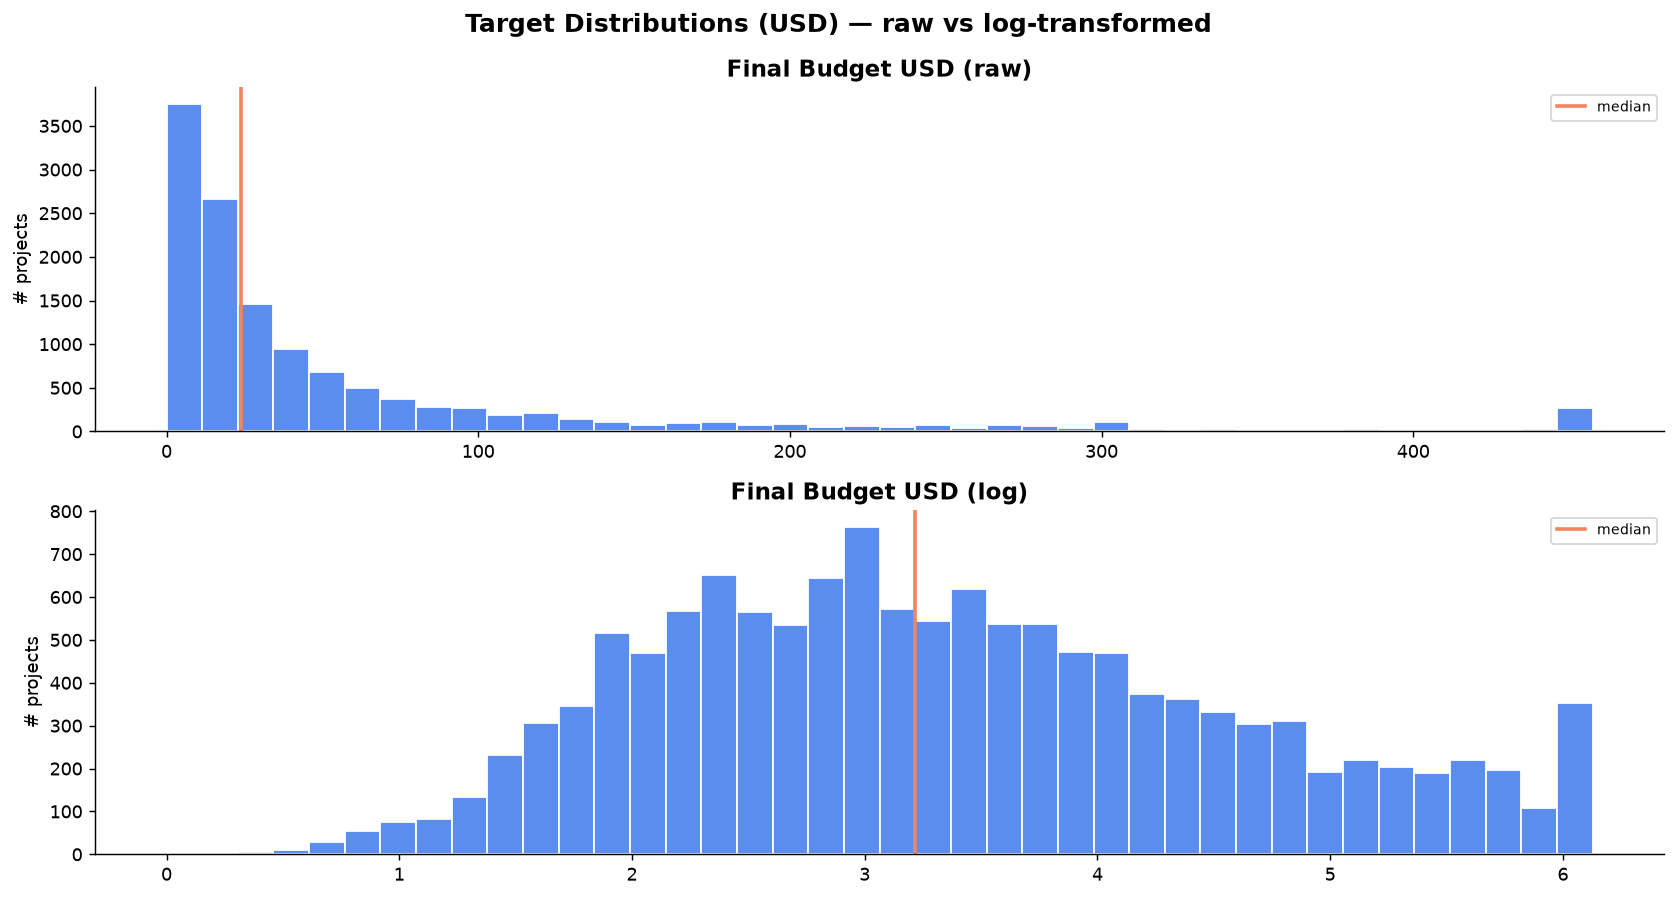

In [51]:
# Drop rows with no usable USD rate first — everything downstream is USD-denominated.
df = df_raw[df_raw['usd_rate'].notna()].copy() if REQUIRE_USD_RATE else df_raw.copy()
n_dropped_no_rate = len(df_raw) - len(df)
PCT_THRESHOLD = 0.10
PRICE_THRESHOLD_UP = 1000000
PRICE_THRESHOLD_DOWN = 0
# ── Budget (USD) ─────────────────────────────────────────────────────────
def resolve_final_budget(row):
    if row['final_budget_usd'] > PRICE_THRESHOLD_UP or row['final_budget_usd'] < PRICE_THRESHOLD_DOWN :
        return np.nan, False 
    if pd.notna(row['final_budget_usd']) and row["final_budget_usd"] != 0 and not row['final_budget_usd'] < row['budget_min_usd'] * (1 - PCT_THRESHOLD):
        return row['final_budget_usd'], False   # (value, is_imputed)
    ratio = row['budget_max_usd'] / max(row['budget_min_usd'], 1e-6)
    if ratio <= BUDGET_RATIO_THRESHOLD:
        estimated_final_price =  (row['budget_min_usd'] + row['budget_max_usd']) / 2
        if estimated_final_price > PRICE_THRESHOLD_UP or estimated_final_price < PRICE_THRESHOLD_DOWN :
            return np.nan, False 
        return estimated_final_price, True
    # return np.nan, False   # ratio too high → will be dropped

df[['target_budget', 'is_budget_imputed']] = df.apply(
    lambda r: pd.Series(resolve_final_budget(r)), axis=1
)
before = len(df)
df = df[df['target_budget'].notna()].copy()
dropped = before - len(df)

# ── Duration ─────────────────────────────────────────────────────────────
duration_median = df['duration_days'].median()
df['is_days_null'] = df['duration_days'].isna().astype(int)
df['duration_days'] = df['duration_days'].fillna(duration_median)

# ── Log-transform targets (right-skewed money/time values) ────────────────
df['log_target_budget']   = np.log1p(df['target_budget'])

print(f'Rows dropped (no USD rate): {n_dropped_no_rate:,}')
print(f'Rows before: {before:,}  |  dropped (ratio too high): {dropped}  |  kept: {len(df):,}')
print(f'Budget imputed (avg min/max): {df.is_budget_imputed.sum()}')
print(f'Duration filled with median ({duration_median:.0f} days): {df.is_days_null.sum()}')
print(f'Data After Cleaning: {len(df)}')

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, col, label in [
    (axes[0], 'target_budget',       'Final Budget USD (raw)'),
    (axes[1], 'log_target_budget',   'Final Budget USD (log)'),
]:
    ax.hist(df[col].clip(upper=df[col].quantile(0.98)), bins=40, color=ACCENT, edgecolor='white')
    ax.axvline(df[col].median(), color=ACCENT2, linewidth=2, label='median')
    ax.set_title(label); ax.set_ylabel('# projects'); ax.legend(fontsize=8)
fig.suptitle('Target Distributions (USD) — raw vs log-transformed', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Sample Weighting Types

In [40]:
import json
import numpy as np
import pandas as pd

# ============================================================
# Load confidence feature names from taxonomy
# ============================================================

with open("taxonomy/taxonomy.json", "r", encoding="utf-8") as f:
    taxonomy = json.load(f)

CONFIDENCE_FEATURES = [
    c for c in list(taxonomy["features"]["values"])
    if c in df_raw.columns
]

print(df_raw.columns)

print(f"Found {len(CONFIDENCE_FEATURES)} confidence features.")

# ============================================================
# Confidence preprocessing
# ============================================================

# Available modes:
#
# A      -> Keep original (0,1,2,3,4,5)
# B      -> Remove weak detections (1,2 -> 0)
# C      -> Binary presence (3,4,5 -> 1)
# MAP    -> Manual nonlinear mapping
# POWER  -> (confidence / 5)^2

CONFIDENCE_MAP = {
    0: 0.00,
    1: 0.02,
    2: 0.08,
    3: 0.35,
    4: 0.75,
    5: 1.00,
}


def transform_confidence(df, mode="A"):
    """
    Transform only taxonomy confidence features.

    Parameters
    ----------
    df : pandas.DataFrame

    mode : str
        "A"      -> original
        "B"      -> 1,2 become 0
        "C"      -> binary (>=3 -> 1)
        "MAP"    -> manual nonlinear mapping
        "POWER"  -> (x/5)^2

    Returns
    -------
    pandas.DataFrame
    """

    df = df.copy()

    mode = mode.upper()

    if mode == "A":
        pass

    elif mode == "B":

        df[CONFIDENCE_FEATURES] = df[CONFIDENCE_FEATURES].replace({
            1: 0,
            2: 0,
        })

    elif mode == "C":

        df[CONFIDENCE_FEATURES] = (
            df[CONFIDENCE_FEATURES] >= 3
        ).astype(np.int8)

    elif mode == "MAP":

        df[CONFIDENCE_FEATURES] = (
            df[CONFIDENCE_FEATURES]
            .replace(CONFIDENCE_MAP)
            .astype(np.float32)
        )

    elif mode == "POWER":

        df[CONFIDENCE_FEATURES] = (
            (df[CONFIDENCE_FEATURES] / 5.0) ** 2
        ).astype(np.float32)

    else:
        raise ValueError(f"Unknown mode '{mode}'")

    return df

Index(['project_id', 'scraped_project_id', 'title', 'category', 'organization',
       'outer_link', 'created_at', 'scraped_date_created', 'usd_rate',
       'usd_rate_date',
       ...
       'data_volume', 'integration_complexity', 'ui_complexity',
       'algorithmic_complexity', 'updated_at', 'category_scraped_id',
       'feature_score_sum', 'feature_count', 'feature_score_mean',
       'feature_score_max'],
      dtype='str', length=165)
Found 82 confidence features.


## 4 · Feature engineering & encoding

In [54]:


# ============================================================
# Ordered categorical columns
# ============================================================

PROJECT_TYPE_COL = "project_type"

ORDINAL_COLS = [
    "ai_level",
    "business_logic",
    "data_volume",
    "integration_complexity",
    "ui_complexity",
    "algorithmic_complexity",
]

ENUM_ORDER = {
    "ai_level": ["none", "basic", "advanced"],
    "business_logic": ["low", "medium", "high"],
    "data_volume": ["small", "medium", "large"],
    "integration_complexity": ["low", "medium", "high"],
    "ui_complexity": ["low", "medium", "high"],
    "algorithmic_complexity": ["low", "medium", "high"],
}

# ============================================================
# Keep only columns that exist and are used as features
# ============================================================

ordinal_cols_present = [
    c for c in ORDINAL_COLS
    if c in df.columns and c not in NON_FEATURE
]

project_type_present = (
    [PROJECT_TYPE_COL]
    if PROJECT_TYPE_COL in df.columns and PROJECT_TYPE_COL not in NON_FEATURE
    else []
)

cols_to_clean = ordinal_cols_present + project_type_present

# ============================================================
# Normalize string values
# ============================================================

if cols_to_clean:
    df[cols_to_clean] = (
        df[cols_to_clean]
        .astype(str)
        .apply(lambda s: s.str.strip().str.lower())
    )

# ============================================================
# Show values before encoding
# ============================================================

print("=== Enum values before encoding ===")

# for col in cols_to_clean:
#     print(f"\n{col}")
#     print(df[col].value_counts(dropna=False).head(20))

# ============================================================
# Ordinal encode ordered columns
# ============================================================

if ordinal_cols_present:

    enc = OrdinalEncoder(
        categories=[ENUM_ORDER[c] for c in ordinal_cols_present],
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )

    df[ordinal_cols_present] = enc.fit_transform(
        df[ordinal_cols_present]
    )

# ============================================================
# One-hot encode project_type
# ============================================================

if project_type_present:

    df = pd.get_dummies(
        df,
        columns=project_type_present,
        prefix="project_type",
        dtype=np.int8,
    )

# ============================================================
# Build feature list
# ============================================================

ALL_FEATURES = [
    c
    for c in df.columns
    if c not in NON_FEATURE and df[c].dtype != object
]

print(f"\nNumber of features: {len(ALL_FEATURES)}")

# ============================================================
# Prepare train/test
# ============================================================
MODE="A"
df_model = transform_confidence(df, MODE)

X = df_model[ALL_FEATURES]
yB = df_model["log_target_budget"]

# First split: separate out test (held out, touched once)
X_temp, X_te, yB_temp, yB_te = train_test_split(
    X,
    yB,
    test_size=0.15,
    random_state=42,
)

# Second split: divide remainder into train / validation
X_tr, X_val, yB_tr, yB_val = train_test_split(
    X_temp,
    yB_temp,
    test_size=0.1765,  # 0.1765 * 0.85 ≈ 0.15 → 70/15/15 overall
    random_state=42,
)

print(f"Train: {len(X_tr)} ({len(X_tr)/len(X):.1%})")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X):.1%})")
print(f"Test:  {len(X_te)} ({len(X_te)/len(X):.1%})")

# print(X_te.head(2))

=== Enum values before encoding ===

Number of features: 110
Train: 9173 (70.0%)
Val:   1967 (15.0%)
Test:  1966 (15.0%)


## Linear Regression


LinearRegression_None
Weight mode    : none
Train R²       : 0.4083
Test  R²       : 0.3981
RMSE (log)     : 0.9760
MAE            : 50
Coverage ±10% : 7.93%
Coverage ±20% : 15.46%
Coverage ±30% : 23.91%
Coverage ±50% : 40.34%


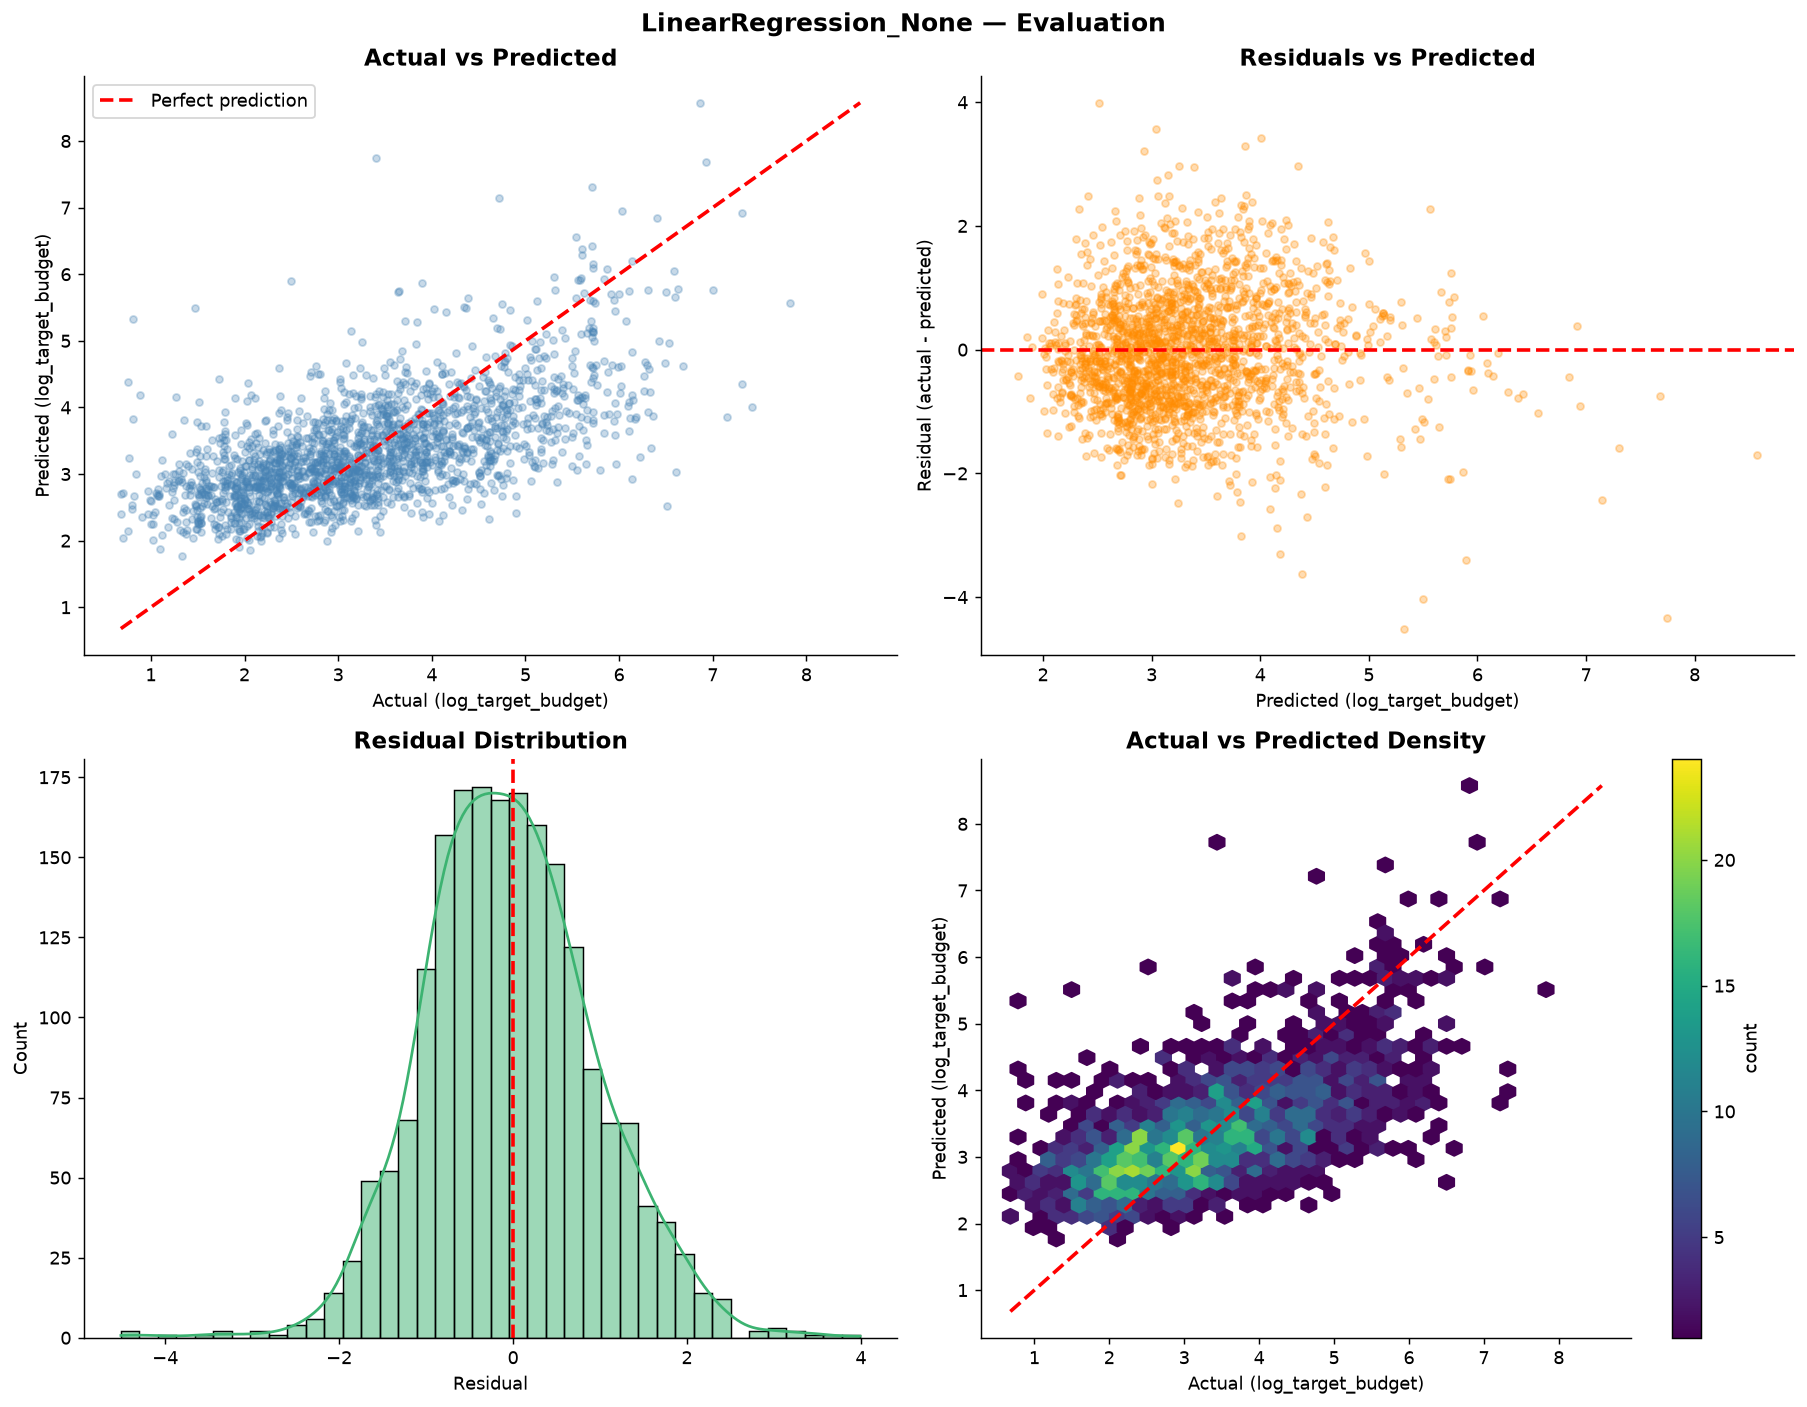

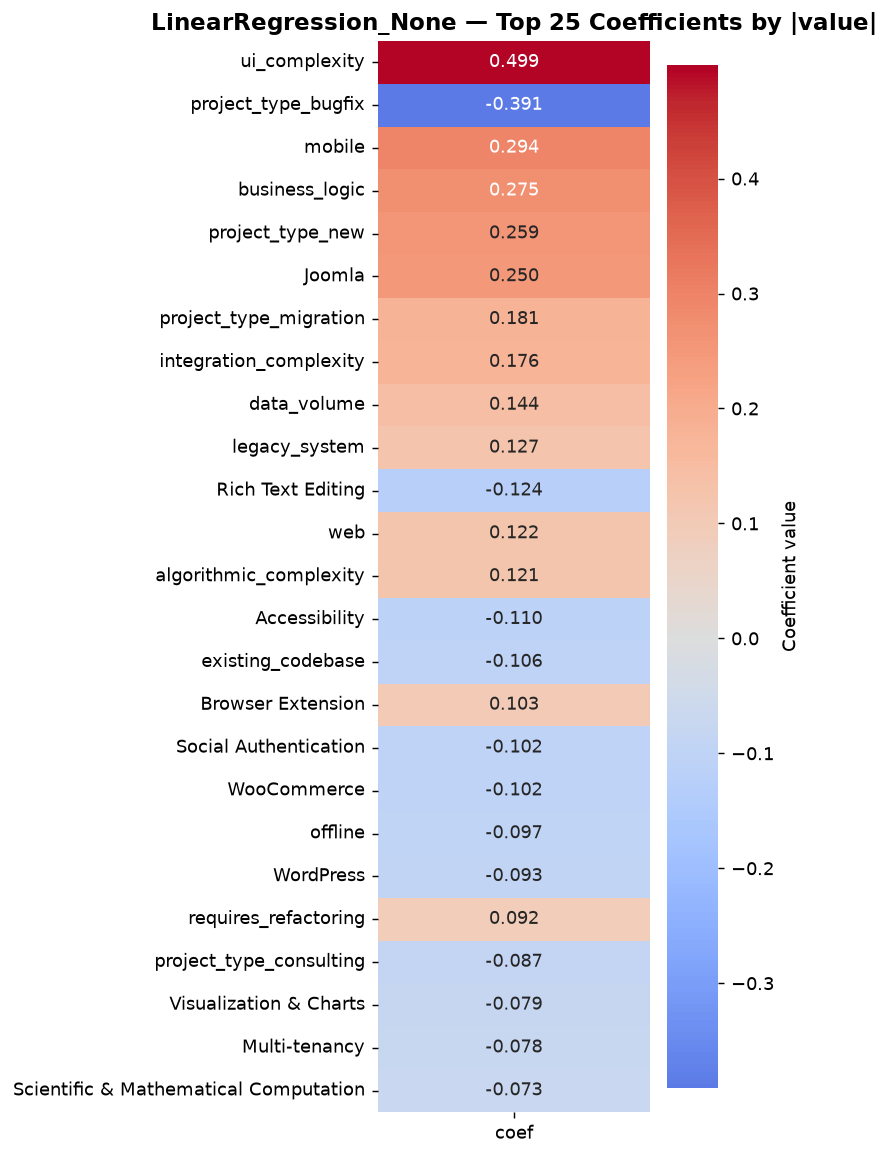

In [42]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Train + Evaluate Linear Regression
# ============================================================

def evaluate_linreg(
    X_tr,
    y_tr,
    X_te,
    y_te,
    name,
    weight_mode="sqrt",   # none | log | sqrt | linear
):

    # --------------------------------------------------------
    # Sample weights (same logic as CatBoost version)
    # --------------------------------------------------------

    budget_train = np.expm1(y_tr)

    if weight_mode == "none":
        sample_weight = None
    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)
    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)
    elif weight_mode == "linear":
        sample_weight = budget_train
    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = LinearRegression()

    model.fit(
        X_tr,
        y_tr,
        sample_weight=sample_weight,
    )

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mae_te = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    r2_tr = r2_score(y_tr, pred_tr)
    r2_te = r2_score(y_te, pred_te)

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Weight mode    : {weight_mode}")
    print(f"Train R²       : {r2_tr:.4f}")
    print(f"Test  R²       : {r2_te:.4f}")
    print(f"RMSE (log)     : {rmse_te:.4f}")
    print(f"MAE            : {mae_te:,.0f}")

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"Coverage ±10% : {cov10:.2%}")
    print(f"Coverage ±20% : {cov20:.2%}")
    print(f"Coverage ±30% : {cov30:.2%}")
    print(f"Coverage ±50% : {cov50:.2%}")

    # --------------------------------------------------------
    # Plots
    # --------------------------------------------------------

    residuals = y_te - pred_te

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(f"{name} — Evaluation", fontsize=14, fontweight="bold")

    # 1) Actual vs Predicted (log target)
    ax = axes[0, 0]
    ax.scatter(y_te, pred_te, alpha=0.3, s=15, color="steelblue")
    lims = [min(y_te.min(), pred_te.min()), max(y_te.max(), pred_te.max())]
    ax.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
    ax.set_xlabel("Actual (log_target_budget)")
    ax.set_ylabel("Predicted (log_target_budget)")
    ax.set_title("Actual vs Predicted")
    ax.legend()

    # 2) Residuals vs Predicted
    ax = axes[0, 1]
    ax.scatter(pred_te, residuals, alpha=0.3, s=15, color="darkorange")
    ax.axhline(0, color="red", linestyle="--", lw=2)
    ax.set_xlabel("Predicted (log_target_budget)")
    ax.set_ylabel("Residual (actual - predicted)")
    ax.set_title("Residuals vs Predicted")

    # 3) Residual distribution
    ax = axes[1, 0]
    sns.histplot(residuals, bins=40, kde=True, ax=ax, color="mediumseagreen")
    ax.axvline(0, color="red", linestyle="--", lw=2)
    ax.set_xlabel("Residual")
    ax.set_title("Residual Distribution")

    # 4) Actual vs Predicted density heatmap (hexbin)
    ax = axes[1, 1]
    hb = ax.hexbin(y_te, pred_te, gridsize=35, cmap="viridis", mincnt=1)
    ax.plot(lims, lims, "r--", lw=2)
    ax.set_xlabel("Actual (log_target_budget)")
    ax.set_ylabel("Predicted (log_target_budget)")
    ax.set_title("Actual vs Predicted Density")
    fig.colorbar(hb, ax=ax, label="count")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Coefficient heatmap (top N by |coef|)
    # --------------------------------------------------------

    if hasattr(X_tr, "columns"):
        coefs = pd.Series(model.coef_, index=X_tr.columns)
        top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index[:25])

        plt.figure(figsize=(6, 9))
        sns.heatmap(
            top_coefs.to_frame(name="coef"),
            annot=True,
            fmt=".3f",
            cmap="coolwarm",
            center=0,
            cbar_kws={"label": "Coefficient value"},
        )
        plt.title(f"{name} — Top 25 Coefficients by |value|")
        plt.tight_layout()
        plt.show()

    return {
        "model": model,
        "pred_test": pred_te,
        "r2_train": r2_tr,
        "r2_test": r2_te,
        "mae_test": mae_te,
    }


# ============================================================
# Train
# ============================================================

lin_none = evaluate_linreg(
    X_tr,
    yB_tr,
    X_te,
    yB_te,
    "LinearRegression_None",
    weight_mode="none",
)

## PCA plotting

PC1 explains 7.52% of variance
PC2 explains 5.00% of variance
Combined: 12.53%


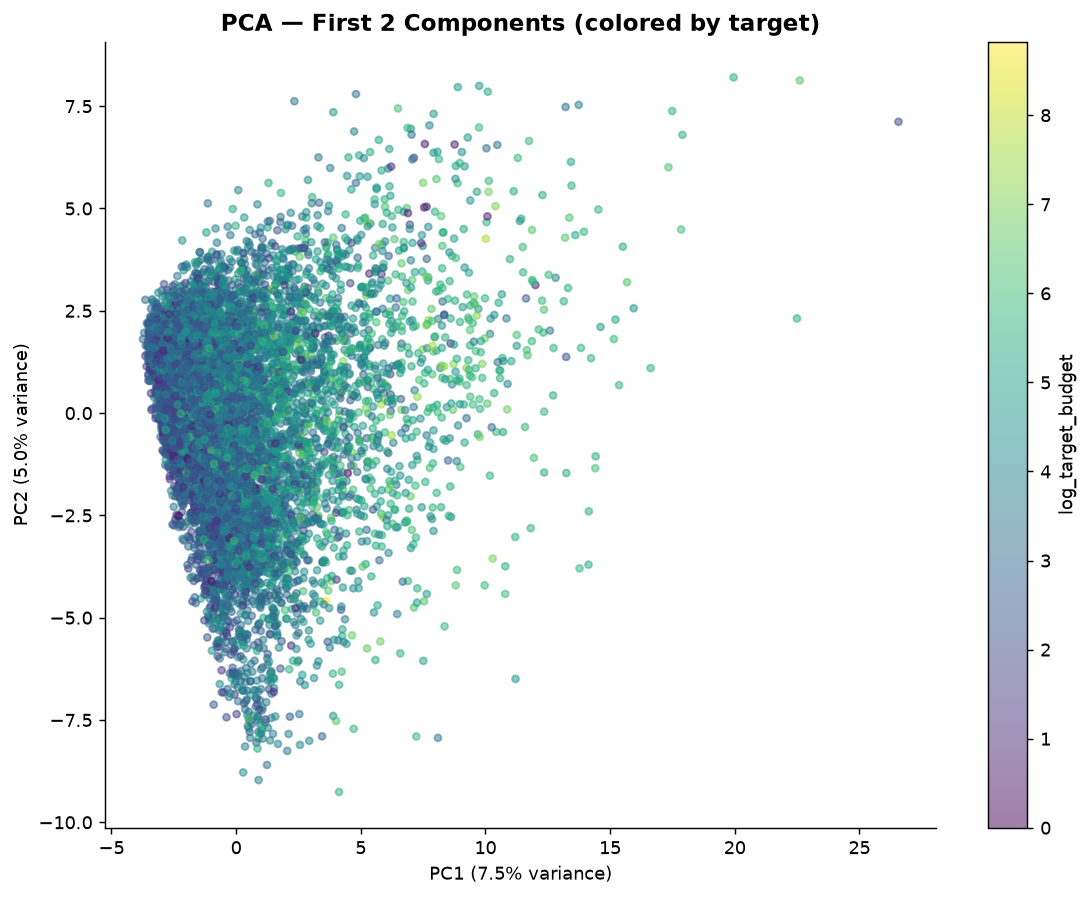

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ============================================================
# PCA on training features
# ============================================================

# Standardize first — PCA is scale-sensitive and your features
# mix one-hot columns with raw-scale numeric ones
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tr)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]:.2%} of variance")
print(f"PC2 explains {explained[1]:.2%} of variance")
print(f"Combined: {explained.sum():.2%}")

# --------------------------------------------------------
# Plot — colored by target (log_target_budget)
# --------------------------------------------------------

plt.figure(figsize=(9, 7))
sc = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=yB_tr,
    cmap="viridis",
    alpha=0.5,
    s=15,
)
plt.colorbar(sc, label="log_target_budget")
plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.title("PCA — First 2 Components (colored by target)")
plt.tight_layout()
plt.show()

## Cat Boost With Validation

In [44]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import itertools

# ============================================================
# Train + Evaluate CatBoost (fixed to use passed-in val set)
# ============================================================

def evaluate_catboost(
    X_tr, y_tr,
    X_val, y_val,
    X_te, y_te,
    name,
    weight_mode="sqrt",
    depth=6,
    l2_leaf_reg=10,
    learning_rate=0.02,
    bagging_temperature=1,
    verbose=0,
):
    budget_train = np.expm1(y_tr)

    if weight_mode == "none":
        sample_weight = None
    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)
    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)
    elif weight_mode == "linear":
        sample_weight = budget_train
    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        bootstrap_type="Bayesian",
        bagging_temperature=bagging_temperature,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        early_stopping_rounds=200,
        verbose=verbose,
    )

    model.fit(
        X_tr, y_tr,
        sample_weight=sample_weight,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    pred_tr = model.predict(X_tr)
    pred_val = model.predict(X_val)
    pred_te = model.predict(X_te)

    r2_tr = r2_score(y_tr, pred_tr)
    r2_val = r2_score(y_val, pred_val)
    r2_te = r2_score(y_te, pred_te)

    mae_val = mean_absolute_error(np.expm1(y_val), np.expm1(pred_val))
    mae_te = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))

    return {
        "model": model,
        "best_iteration": model.get_best_iteration(),
        "pred_val": pred_val,
        "pred_test": pred_te,
        "r2_train": r2_tr,
        "r2_val": r2_val,
        "r2_test": r2_te,
        "mae_val": mae_val,
        "mae_test": mae_te,
        "rmse_test": rmse_te,
    }


# ============================================================
# Hyperparameter grid search — evaluated on VALIDATION
# ============================================================

def tune_catboost(
    X_tr, y_tr,
    X_val, y_val,
    weight_mode="none",
    depths=(4,5),
    l2_leaf_regs=(3,1),
    learning_rates=(0.01,1 ),
    bagging_temperatures=(0,1),
):
    grid = list(itertools.product(depths, l2_leaf_regs, learning_rates, bagging_temperatures))
    print(f"Sweeping {len(grid)} combinations...")

    results = []

    for i, (depth, l2, lr, bt) in enumerate(grid, 1):
        res = evaluate_catboost(
            X_tr, y_tr,
            X_val, y_val,
            X_val, y_val,   # test slot unused here — just reusing val for the call
            name=f"combo_{i}",
            weight_mode=weight_mode,
            depth=depth,
            l2_leaf_reg=l2,
            learning_rate=lr,
            bagging_temperature=bt,
            verbose=0,
        )

        results.append({
            "depth": depth,
            "l2_leaf_reg": l2,
            "learning_rate": lr,
            "bagging_temperature": bt,
            "best_iteration": res["best_iteration"],
            "r2_val": res["r2_val"],
            "mae_val": res["mae_val"],
        })

        print(f"[{i}/{len(grid)}] depth={depth} l2={l2} lr={lr} bt={bt} "
              f"-> val R²={res['r2_val']:.4f}, val MAE={res['mae_val']:,.0f}")

    results_df = pd.DataFrame(results).sort_values("r2_val", ascending=False).reset_index(drop=True)

    print(f"\n{'='*70}")
    print("Top 10 combinations by validation R²")
    print(f"{'='*70}")
    print(results_df.head(10).to_string(index=False))

    best = results_df.iloc[0]
    print(f"\nBest params: depth={best['depth']}, l2_leaf_reg={best['l2_leaf_reg']}, "
          f"learning_rate={best['learning_rate']}, bagging_temperature={best['bagging_temperature']}")
    print(f"Best val R²: {best['r2_val']:.4f}")

    return results_df, best


# ============================================================
# Run sweep
# ============================================================

cat_results, best_cat_params = tune_catboost(
    X_tr, yB_tr,
    X_val, yB_val,
    weight_mode="none",
)

Sweeping 16 combinations...
[1/16] depth=4 l2=3 lr=0.01 bt=0 -> val R²=0.4873, val MAE=47
[2/16] depth=4 l2=3 lr=0.01 bt=1 -> val R²=0.4894, val MAE=48
[3/16] depth=4 l2=3 lr=1 bt=0 -> val R²=0.4642, val MAE=49
[4/16] depth=4 l2=3 lr=1 bt=1 -> val R²=0.4555, val MAE=49
[5/16] depth=4 l2=1 lr=0.01 bt=0 -> val R²=0.4879, val MAE=48
[6/16] depth=4 l2=1 lr=0.01 bt=1 -> val R²=0.4898, val MAE=48
[7/16] depth=4 l2=1 lr=1 bt=0 -> val R²=0.4604, val MAE=49
[8/16] depth=4 l2=1 lr=1 bt=1 -> val R²=0.4442, val MAE=49
[9/16] depth=5 l2=3 lr=0.01 bt=0 -> val R²=0.4903, val MAE=48
[10/16] depth=5 l2=3 lr=0.01 bt=1 -> val R²=0.4905, val MAE=48
[11/16] depth=5 l2=3 lr=1 bt=0 -> val R²=0.4698, val MAE=50
[12/16] depth=5 l2=3 lr=1 bt=1 -> val R²=0.4542, val MAE=50
[13/16] depth=5 l2=1 lr=0.01 bt=0 -> val R²=0.4901, val MAE=48
[14/16] depth=5 l2=1 lr=0.01 bt=1 -> val R²=0.4907, val MAE=48
[15/16] depth=5 l2=1 lr=1 bt=0 -> val R²=0.4617, val MAE=50
[16/16] depth=5 l2=1 lr=1 bt=1 -> val R²=0.4500, val MAE=

In [45]:
# ============================================================
# Final CatBoost — best params, evaluated on TEST once
# ============================================================

cat_final = evaluate_catboost(
    X_tr, yB_tr,
    X_val, yB_val,
    X_te, yB_te,
    name="CatBoost_Final",
    weight_mode="none",
    depth=int(best_cat_params["depth"]),
    l2_leaf_reg=best_cat_params["l2_leaf_reg"],
    learning_rate=best_cat_params["learning_rate"],
    bagging_temperature=best_cat_params["bagging_temperature"],
    verbose=100,
)

print(f"\nFinal Test R²  : {cat_final['r2_test']:.4f}")
print(f"Final Test MAE : {cat_final['mae_test']:,.0f}")
print(f"Final Test RMSE: {cat_final['rmse_test']:.4f}")

0:	learn: 1.2508369	test: 1.2689058	best: 1.2689058 (0)	total: 11.1ms	remaining: 55.5s
100:	learn: 1.0099409	test: 1.0265686	best: 1.0265686 (100)	total: 325ms	remaining: 15.8s
200:	learn: 0.9488751	test: 0.9633575	best: 0.9633575 (200)	total: 652ms	remaining: 15.6s
300:	learn: 0.9271366	test: 0.9430324	best: 0.9430324 (300)	total: 942ms	remaining: 14.7s
400:	learn: 0.9160483	test: 0.9345456	best: 0.9345456 (400)	total: 1.22s	remaining: 14s
500:	learn: 0.9085622	test: 0.9301872	best: 0.9301872 (500)	total: 1.5s	remaining: 13.5s
600:	learn: 0.9027345	test: 0.9274408	best: 0.9274408 (600)	total: 1.78s	remaining: 13s
700:	learn: 0.8979077	test: 0.9254661	best: 0.9254661 (700)	total: 2.06s	remaining: 12.6s
800:	learn: 0.8934549	test: 0.9238151	best: 0.9238151 (800)	total: 2.33s	remaining: 12.2s
900:	learn: 0.8890049	test: 0.9223035	best: 0.9222941 (897)	total: 2.61s	remaining: 11.9s
1000:	learn: 0.8844770	test: 0.9208643	best: 0.9208643 (1000)	total: 2.9s	remaining: 11.6s
1100:	learn: 0.88

## Save Model

In [ ]:
model = cat_final["model"]


# Save the trained model itself
model.save_model("catboost_price_model.cbm")

project_type_dummy_cols = [c for c in ALL_FEATURES if c.startswith("project_type_")]

feature_schema = {
    "columns": ALL_FEATURES,                      # exact order model was trained on
    "target_transform": "log1p",
    "ordinal_cols": ordinal_cols_present,          # which ordinal cols actually survived NON_FEATURE
    "enum_order": {c: ENUM_ORDER[c] for c in ordinal_cols_present},  # index = encoded value
    "project_type_prefix": "project_type_",
    "project_type_dummy_cols": project_type_dummy_cols,  # exact categories seen in training data
}
with open("catboost_price_model_schema.json", "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)

print(f"Saved model with {len(ALL_FEATURES)} features")
print(f"Ordinal cols in this model: {ordinal_cols_present}")
print(f"project_type dummies in this model: {project_type_dummy_cols}")



Saved model with 110 features
Ordinal cols in this model: ['ai_level', 'business_logic', 'data_volume', 'integration_complexity', 'ui_complexity', 'algorithmic_complexity']
project_type dummies in this model: ['project_type_bugfix', 'project_type_consulting', 'project_type_maintenance', 'project_type_migration', 'project_type_new', 'project_type_optimization', 'project_type_testing']


## 6 · Deep learning approach (feed-forward neural net)
Same features, same log-transformed targets — but a small dense neural network instead of trees. Neural nets need scaled inputs (trees don't), so we standardize features first.

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


# ============================================================
# Scale features
# ============================================================
# IMPORTANT:
# Fit scaler ONLY on training data.
# Validation and test are transformed using the same scaler.

scaler = StandardScaler()

X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_te_scaled = scaler.transform(X_te)

print("Train:", X_tr_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_te_scaled.shape)


# ============================================================
# Build model
# ============================================================

def build_mlp(input_dim, name):

    l2 = regularizers.l2(1e-5)

    model = keras.Sequential([

        layers.Input(shape=(input_dim,)),

        layers.Dense(
            256,
            activation="gelu",
            kernel_regularizer=l2
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Dense(
            128,
            activation="gelu",
            kernel_regularizer=l2
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        layers.Dense(
            64,
            activation="gelu",
            kernel_regularizer=l2
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.10),

        layers.Dense(
            32,
            activation="gelu",
            kernel_regularizer=l2
        ),

        layers.Dense(1),

    ], name=name)

    optimizer = keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    )

    model.compile(
        optimizer=optimizer,

        loss=keras.losses.Huber(
            delta=1.0
        ),

        metrics=[
            "mae",
            keras.metrics.RootMeanSquaredError(
                name="rmse"
            )
        ]
    )

    return model


# ============================================================
# Callbacks
# ============================================================

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
# Train + Validate + Test
# ============================================================

def evaluate_dl(
    X_tr_s,
    y_tr,
    X_val_s,
    y_val,
    X_te_s,
    y_te,
    name,
    epochs=300,
    batch_size=64
):

    # --------------------------------------------------------
    # Build a fresh model
    # --------------------------------------------------------

    model = build_mlp(
        X_tr_s.shape[1],
        name
    )


    # --------------------------------------------------------
    # Train
    #
    # Validation set is explicitly supplied.
    # There is NO validation_split here.
    # --------------------------------------------------------

    history = model.fit(

        X_tr_s,
        y_tr,

        validation_data=(
            X_val_s,
            y_val
        ),

        epochs=epochs,

        batch_size=batch_size,

        callbacks=[
            early_stop,
            reduce_lr
        ],

        verbose=1,

        shuffle=True
    )


    # ========================================================
    # Predictions
    # ========================================================

    pred_tr = (
        model
        .predict(
            X_tr_s,
            verbose=0
        )
        .flatten()
    )

    pred_val = (
        model
        .predict(
            X_val_s,
            verbose=0
        )
        .flatten()
    )

    pred_te = (
        model
        .predict(
            X_te_s,
            verbose=0
        )
        .flatten()
    )


    # ========================================================
    # R² — LOG SPACE
    # ========================================================

    r2_tr_log = r2_score(
        y_tr,
        pred_tr
    )

    r2_val_log = r2_score(
        y_val,
        pred_val
    )

    r2_te_log = r2_score(
        y_te,
        pred_te
    )


    # ========================================================
    # Convert predictions back to ORIGINAL price space
    # ========================================================

    y_val_original = np.expm1(y_val)
    pred_val_original = np.expm1(pred_val)

    y_te_original = np.expm1(y_te)
    pred_te_original = np.expm1(pred_te)


    # ========================================================
    # Original-price metrics
    # ========================================================

    r2_val_original = r2_score(
        y_val_original,
        pred_val_original
    )

    r2_te_original = r2_score(
        y_te_original,
        pred_te_original
    )

    mae_val = mean_absolute_error(
        y_val_original,
        pred_val_original
    )

    mae_te = mean_absolute_error(
        y_te_original,
        pred_te_original
    )

    rmse_val = np.sqrt(
        mean_squared_error(
            y_val_original,
            pred_val_original
        )
    )

    rmse_te = np.sqrt(
        mean_squared_error(
            y_te_original,
            pred_te_original
        )
    )


    # ========================================================
    # Epoch count
    # ========================================================

    n_epochs = len(
        history.history["loss"]
    )


    # ========================================================
    # Print results
    # ========================================================

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(f"Training epochs          : {n_epochs}")

    print()
    print("R² — LOG SPACE")
    print(f"Train R²                 : {r2_tr_log:.4f}")
    print(f"Validation R²            : {r2_val_log:.4f}")
    print(f"Test R²                  : {r2_te_log:.4f}")

    print()
    print("R² — ORIGINAL PRICE SPACE")
    print(f"Validation R²            : {r2_val_original:.4f}")
    print(f"Test R²                  : {r2_te_original:.4f}")

    print()
    print("TEST ERROR — ORIGINAL PRICE")
    print(f"MAE                      : {mae_te:,.2f}")
    print(f"RMSE                     : {rmse_te:,.2f}")


    # ========================================================
    # Coverage
    # ========================================================

    cov10 = interval_accuracy(
        y_te,
        pred_te,
        0.10
    )

    cov20 = interval_accuracy(
        y_te,
        pred_te,
        0.20
    )

    cov30 = interval_accuracy(
        y_te,
        pred_te,
        0.30
    )

    cov50 = interval_accuracy(
        y_te,
        pred_te,
        0.50
    )

    print()
    print("TEST INTERVAL COVERAGE")

    print(
        f"Coverage ±10%           : {cov10:.2%}"
    )

    print(
        f"Coverage ±20%           : {cov20:.2%}"
    )

    print(
        f"Coverage ±30%           : {cov30:.2%}"
    )

    print(
        f"Coverage ±50%           : {cov50:.2%}"
    )


    # ========================================================
    # Return everything
    # ========================================================

    return {

        "model": model,

        "history": history,

        "scaler": scaler,

        "pred_train": pred_tr,

        "pred_val": pred_val,

        "pred_test": pred_te,

        # Log-space R²
        "r2_train": r2_tr_log,
        "r2_val": r2_val_log,
        "r2_test": r2_te_log,

        # Original-space R²
        "r2_val_original": r2_val_original,
        "r2_test_original": r2_te_original,

        # Original-space errors
        "mae_val": mae_val,
        "mae_test": mae_te,

        "rmse_val": rmse_val,
        "rmse_test": rmse_te,

        # Coverage
        "coverage_10": cov10,
        "coverage_20": cov20,
        "coverage_30": cov30,
        "coverage_50": cov50,

        "n_epochs": n_epochs
    }


# ============================================================
# Train MLP
# ============================================================

print(
    "=== Deep Learning Budget Model ==="
)

dl_budget = evaluate_dl(

    X_tr_scaled,
    yB_tr,

    X_val_scaled,
    yB_val,

    X_te_scaled,
    yB_te,

    "MLP_AdamW_Huber"
)

Train: (9173, 110)
Validation: (1967, 110)
Test: (1966, 110)
=== Deep Learning Budget Model ===
Epoch 1/300
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.2203 - mae: 1.6485 - rmse: 2.0832 - val_loss: 0.8367 - val_mae: 1.2407 - val_rmse: 1.5803 - learning_rate: 3.0000e-04
Epoch 2/300
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6127 - mae: 1.0004 - rmse: 1.2841 - val_loss: 0.4883 - val_mae: 0.8656 - val_rmse: 1.1119 - learning_rate: 3.0000e-04
Epoch 3/300
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5305 - mae: 0.9090 - rmse: 1.1638 - val_loss: 0.4507 - val_mae: 0.8210 - val_rmse: 1.0535 - learning_rate: 3.0000e-04
Epoch 4/300
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4839 - mae: 0.8564 - rmse: 1.0977 - val_loss: 0.4394 - val_mae: 0.8074 - val_rmse: 1.0375 - learning_rate: 3.0000e-04
Epoch 5/300
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4624 - mae: 0.8321 - rmse: 1.0663 - val_loss: 0.4282 - val_mae: 0.7956 - val_rmse: 1.0161 - learning_rate: 3.0000e-04

## 7a Training Curve

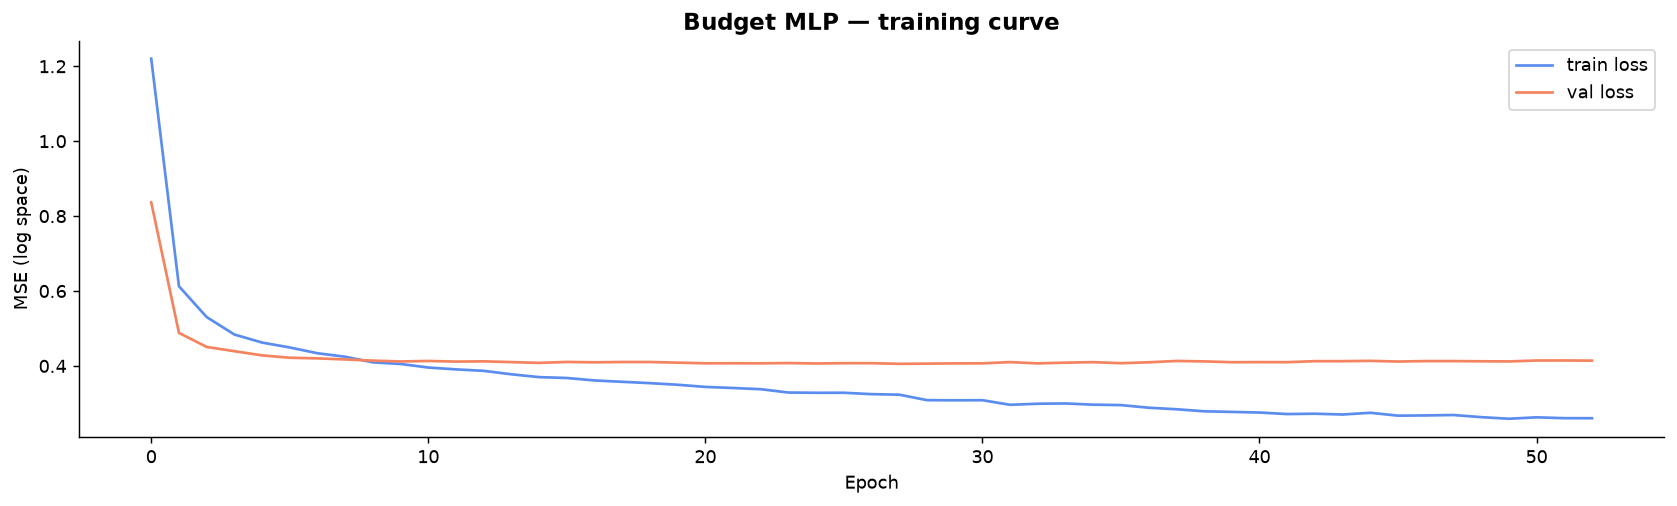

In [48]:
# Training curves — loss over epochs, useful for spotting over/underfitting
fig, axes = plt.subplots(1, 1, figsize=(13, 4))
for ax, res, title in [
    (axes, dl_budget,   'Budget MLP — training curve'),
]:
    h = res['history'].history
    ax.plot(h['loss'], label='train loss', color=ACCENT)
    ax.plot(h['val_loss'], label='val loss', color=ACCENT2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (log space)')
    ax.legend()
plt.tight_layout(); plt.show()


## 8 Feature Importance

=== Budget model feature importance ===


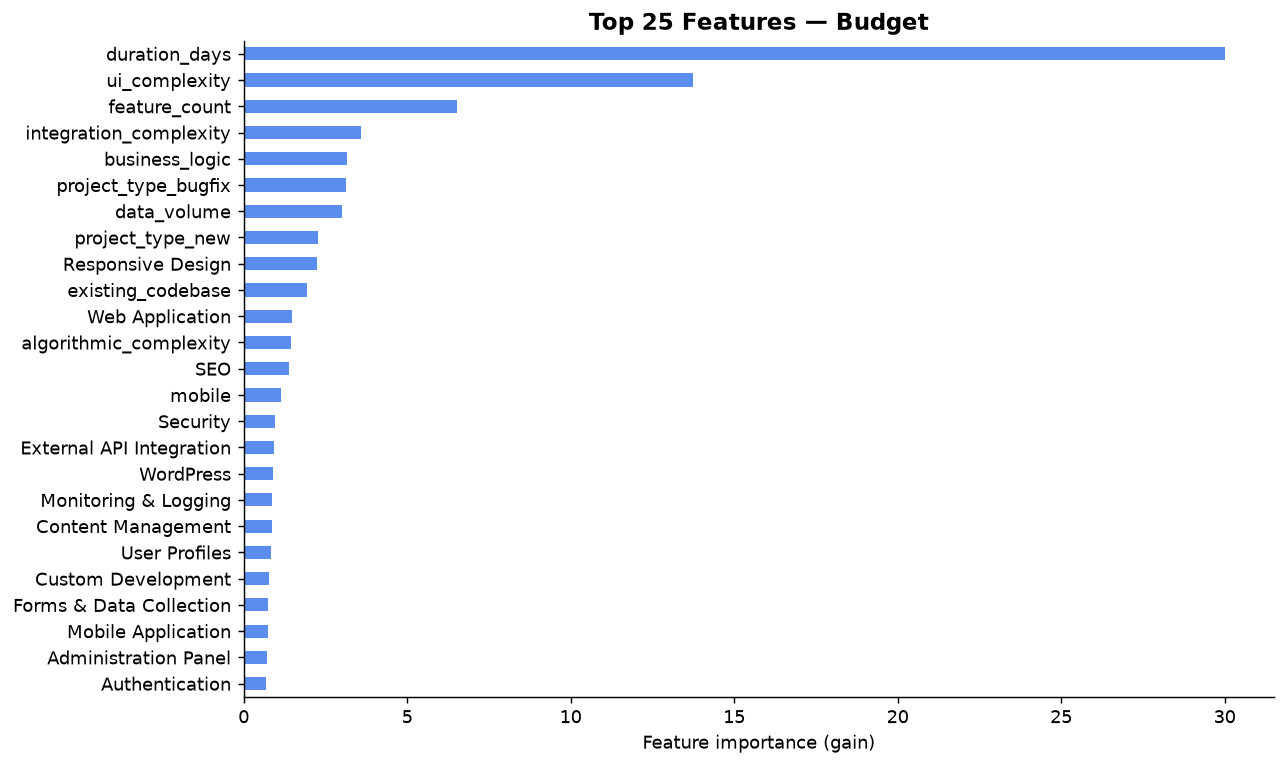

duration_days             30.007408
ui_complexity             13.742879
feature_count              6.534121
integration_complexity     3.573124
business_logic             3.173750
project_type_bugfix        3.124330
data_volume                3.003642
project_type_new           2.268295
Responsive Design          2.236501
existing_codebase          1.942247


In [49]:
TOP_N = 25

def plot_importance(model, feature_names, title, top_n=TOP_N):
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names)
    else:
        return
    imp = imp.nlargest(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    imp[::-1].plot(kind='barh', ax=ax, color=ACCENT)
    ax.set_title(title)
    ax.set_xlabel('Feature importance (gain)')
    plt.tight_layout(); plt.show()
    return imp

print('=== Budget model feature importance ===')
imp_b = plot_importance(cat_none['model'], ALL_FEATURES, f'Top {TOP_N} Features — Budget')
print(imp_b.head(10).to_string())



# Final Unified Evaluation Dashboard

This section compares Linear Regression, grid-search tuned CatBoost, and MLP using identical evaluation plots:
- Actual vs predicted scatter
- Actual vs predicted density heatmap
- Residual analysis
- Feature importance (when available)
- Calibration by prediction decile
- Train/validation loss comparison
- Learning curves


MODEL PERFORMANCE COMPARISON


,Model,R² (log),R² (price),MAE,RMSE
0,Linear Regression,0.3981,-0.5294,50.17,167.99
1,CatBoost,0.4793,0.2547,43.61,117.27
2,MLP,0.3880,0.1833,47.58,122.76


TRAIN / VALIDATION LOSS


,Train Loss,Validation Loss
Linear Regression,0.9326,nan
CatBoost,0.6127,0.8258
MLP,0.2604,0.4141


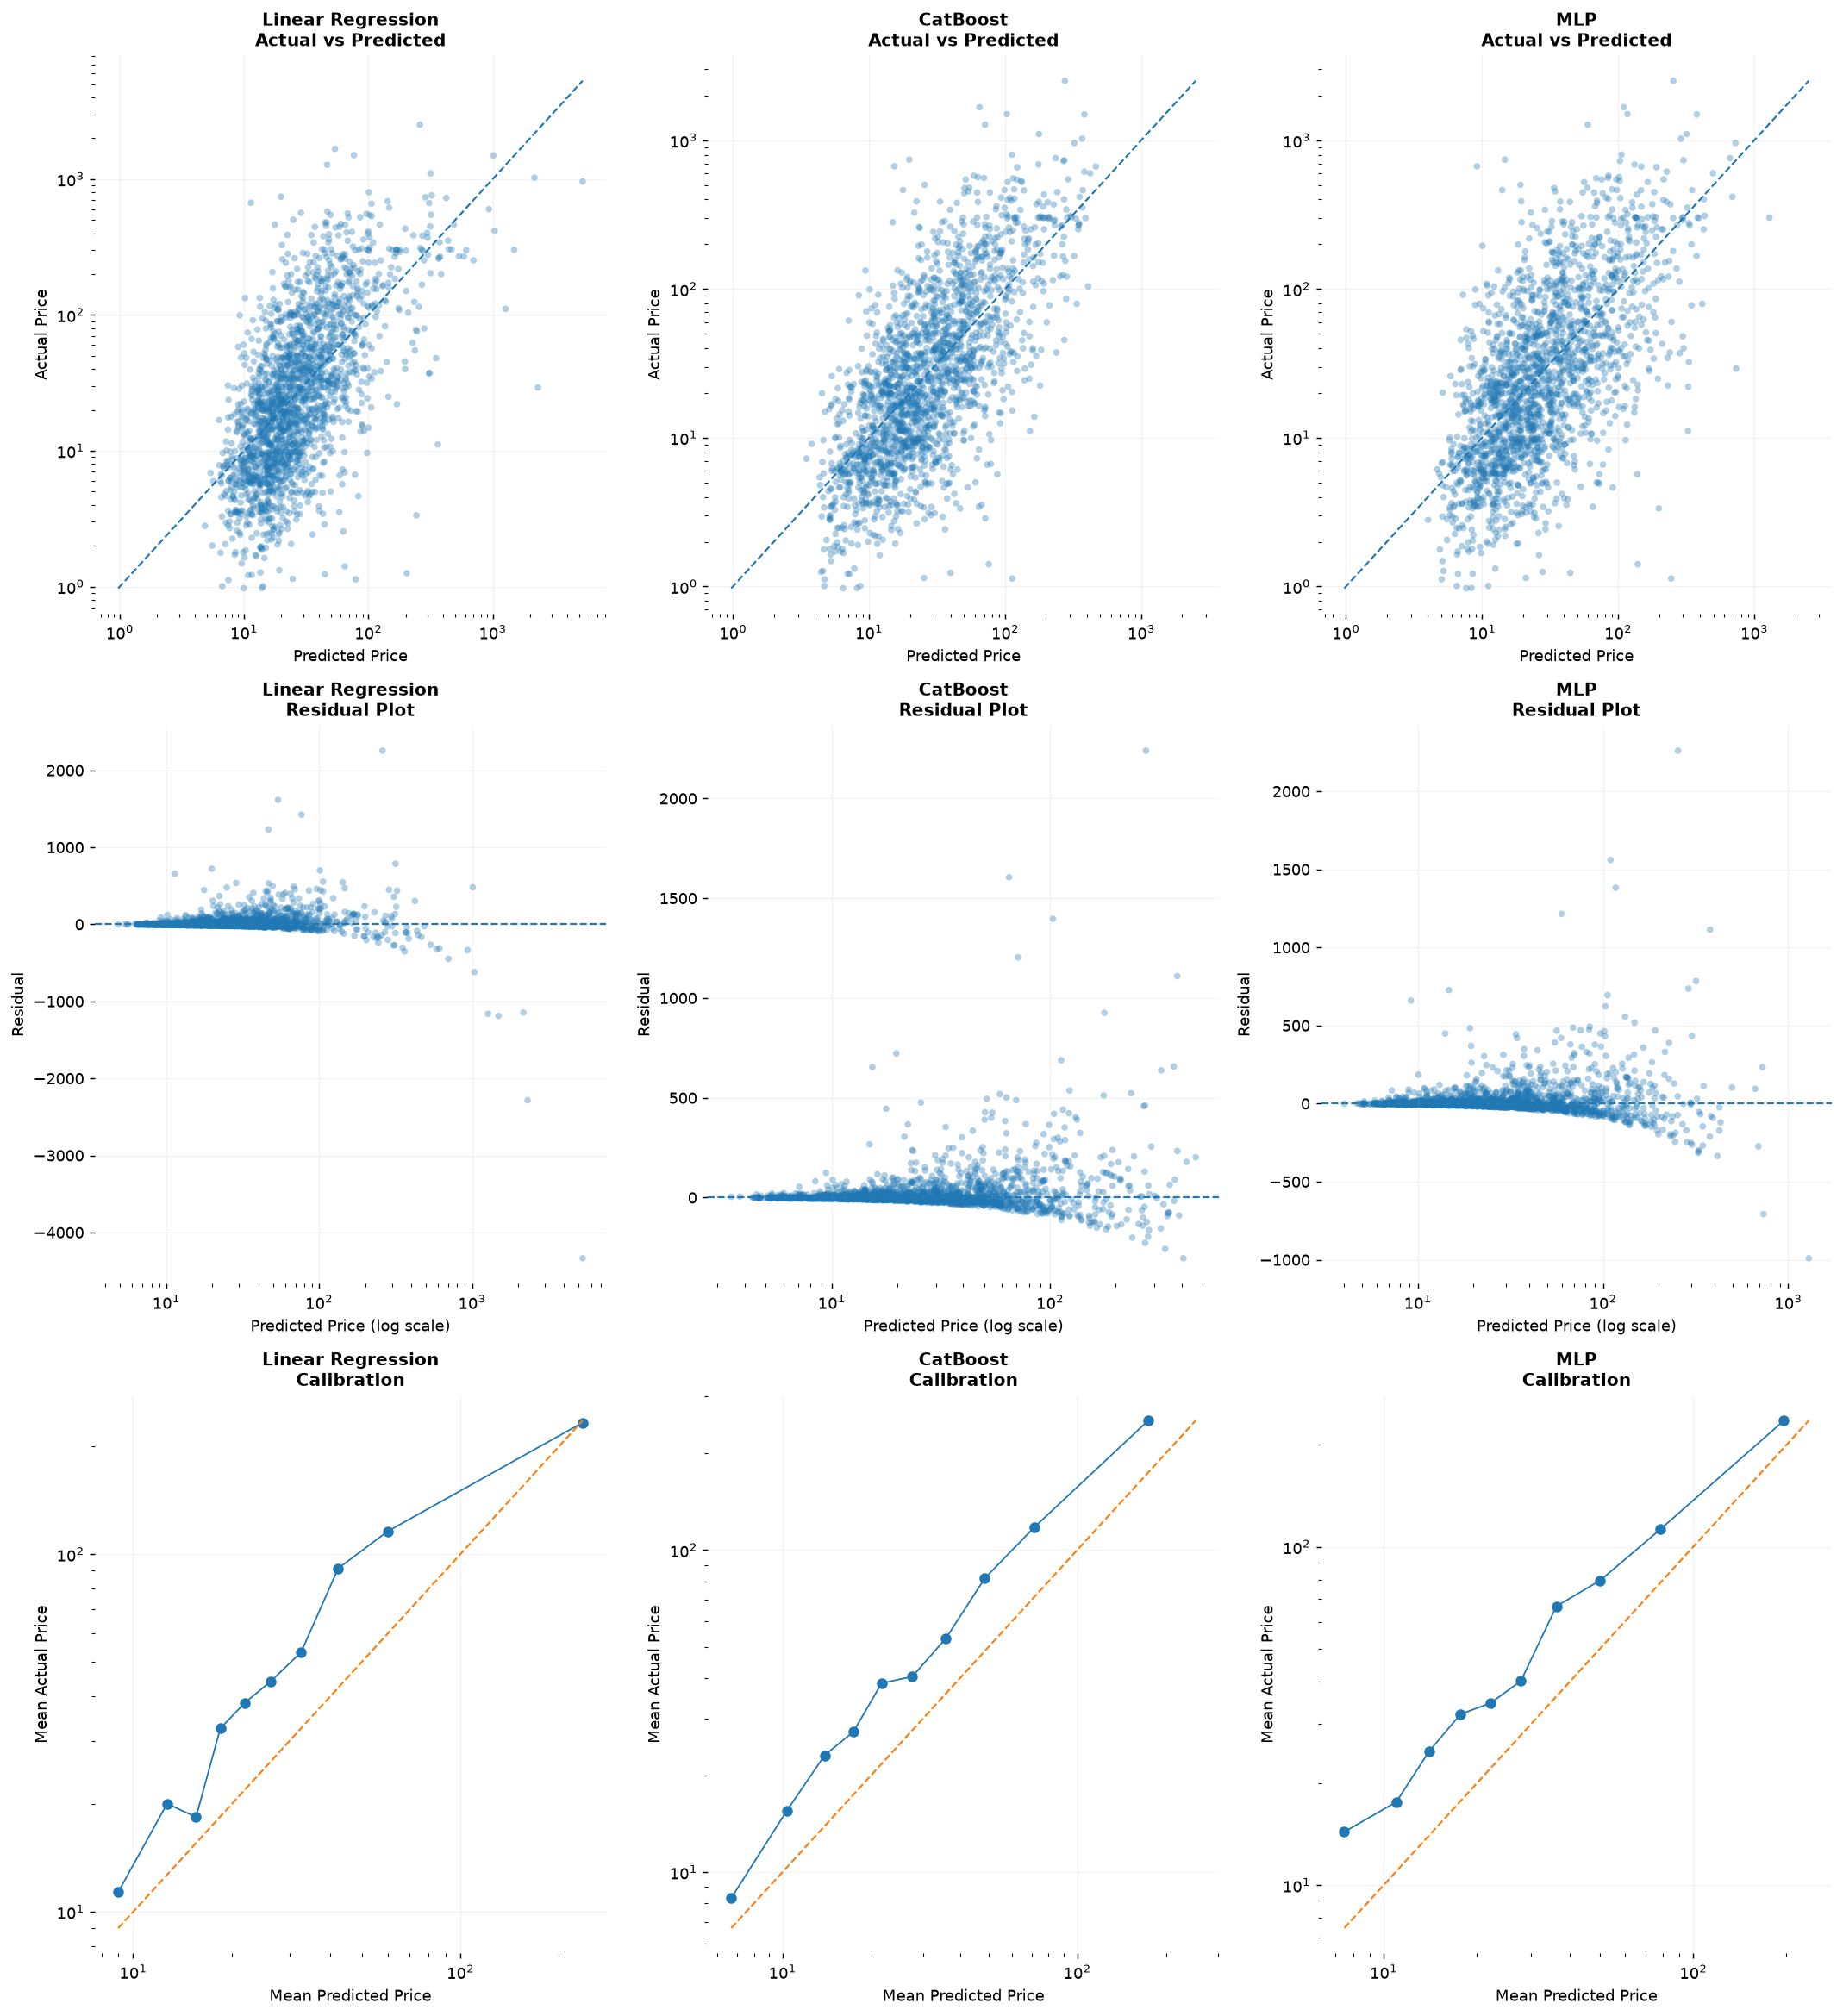

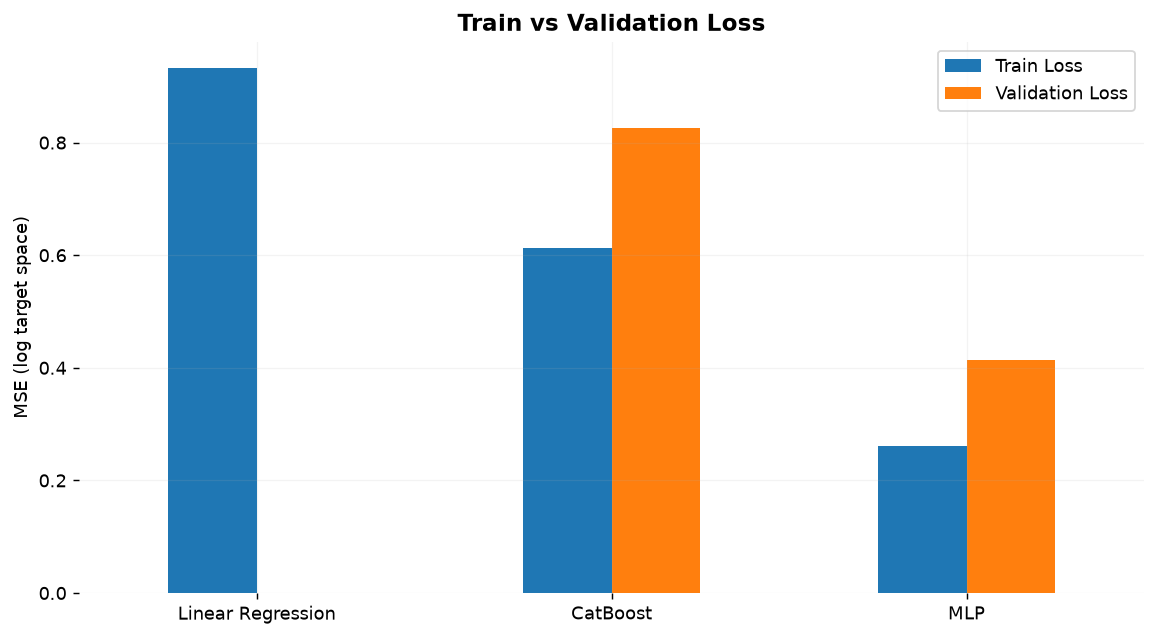

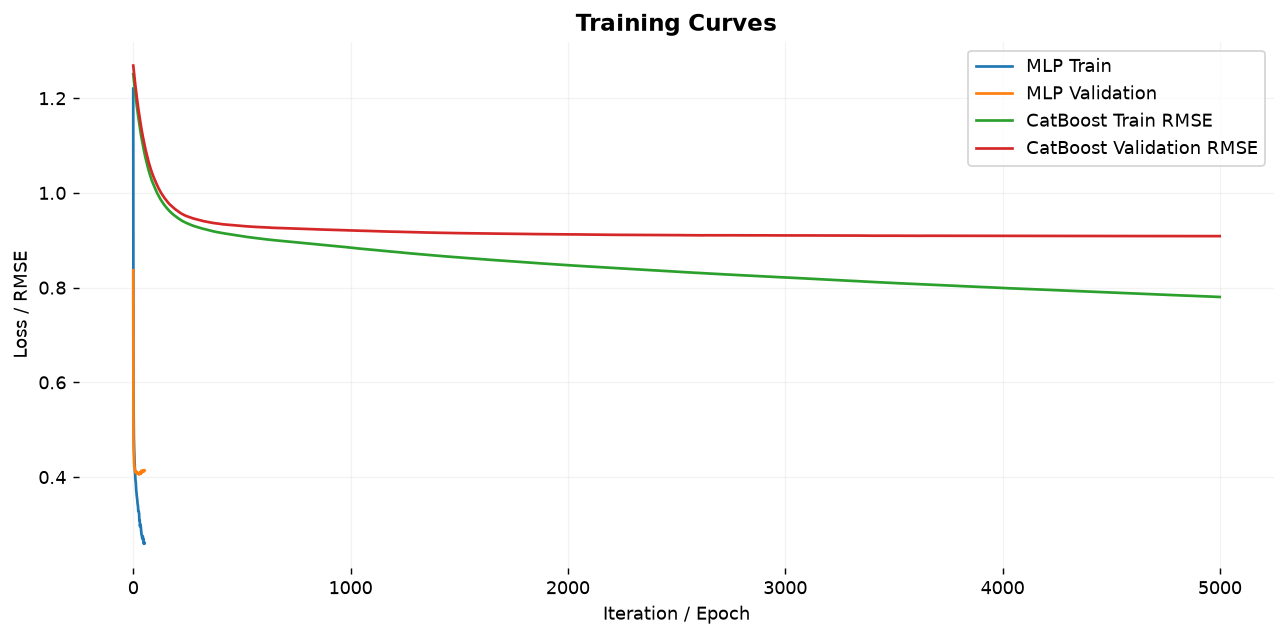

In [50]:
# ============================================================
# Unified Model Comparison Dashboard
# Linear Regression vs CatBoost vs MLP
#
# Metrics:
#   - R² (log space)
#   - R² (original price space)
#   - MAE (original price space)
#   - RMSE (original price space)
#
# Visualizations:
#   Row 1: Actual vs Predicted (log-log)
#   Row 2: Residuals
#   Row 3: Calibration
#   Row 4: Feature Importance / Effect
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# Helper: remove plot outlines
# ============================================================

def clean_axis(ax):
    """
    Remove plot borders/spines for a cleaner dashboard.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.grid(
        True,
        alpha=0.15,
        linewidth=0.7
    )


# ============================================================
# Collect predictions
# ============================================================

models_eval = {}


# ------------------------------------------------------------
# Linear Regression
# ------------------------------------------------------------

lin_pred_test_log = lin_none["pred_test"]
lin_pred_test_original = np.expm1(lin_pred_test_log)

lin_actual_test_original = np.expm1(yB_te)

lin_pred_train_log = lin_none["model"].predict(X_tr)


models_eval["Linear Regression"] = {

    "model": lin_none["model"],

    # Test predictions
    "pred_log": lin_pred_test_log,
    "actual_log": yB_te,

    "pred": lin_pred_test_original,
    "actual": lin_actual_test_original,

    # Training loss in LOG space
    "train_loss": mean_squared_error(
        yB_tr,
        lin_pred_train_log
    ),

    # No validation evaluation for this model
    "val_loss": None,
}


# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

cat_pred_test_log = cat_final["pred_test"]

cat_pred_test_original = np.expm1(
    cat_pred_test_log
)

cat_actual_test_original = np.expm1(
    yB_te
)

cat_pred_train_log = cat_final["model"].predict(
    X_tr
)

cat_pred_val_log = cat_final["model"].predict(
    X_val
)


models_eval["CatBoost"] = {

    "model": cat_final["model"],

    # Test predictions
    "pred_log": cat_pred_test_log,
    "actual_log": yB_te,

    "pred": cat_pred_test_original,
    "actual": cat_actual_test_original,

    # Training loss in LOG space
    "train_loss": mean_squared_error(
        yB_tr,
        cat_pred_train_log
    ),

    # Validation loss in LOG space
    "val_loss": mean_squared_error(
        yB_val,
        cat_pred_val_log
    ),
}


# ------------------------------------------------------------
# MLP
# ------------------------------------------------------------

mlp_pred_test_log = (
    dl_budget["pred_test"]
    .reshape(-1)
)

mlp_pred_test_original = np.expm1(
    mlp_pred_test_log
)

mlp_actual_test_original = np.expm1(
    yB_te
)


models_eval["MLP"] = {

    "model": dl_budget["model"],

    # Test predictions
    "pred_log": mlp_pred_test_log,
    "actual_log": yB_te,

    "pred": mlp_pred_test_original,
    "actual": mlp_actual_test_original,

    # Training / validation loss from Keras history
    "train_loss": (
        dl_budget["history"]
        .history["loss"][-1]
    ),

    "val_loss": (
        dl_budget["history"]
        .history["val_loss"][-1]
    ),
}


# ============================================================
# Calculate metrics
# ============================================================

rows = []

for name, d in models_eval.items():

    # -----------------------------
    # R² in LOG space
    # -----------------------------

    r2_log = r2_score(
        d["actual_log"],
        d["pred_log"]
    )

    # -----------------------------
    # R² in ORIGINAL price space
    # -----------------------------

    r2_original = r2_score(
        d["actual"],
        d["pred"]
    )

    # -----------------------------
    # MAE in ORIGINAL price space
    # -----------------------------

    mae = mean_absolute_error(
        d["actual"],
        d["pred"]
    )

    # -----------------------------
    # RMSE in ORIGINAL price space
    # -----------------------------

    rmse = np.sqrt(
        mean_squared_error(
            d["actual"],
            d["pred"]
        )
    )

    rows.append({
        "Model": name,
        "R² (log)": r2_log,
        "R² (price)": r2_original,
        "MAE": mae,
        "RMSE": rmse
    })


comparison_metrics = pd.DataFrame(rows)


# ============================================================
# Display metrics
# ============================================================

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

display(
    comparison_metrics.style.format({
        "R² (log)": "{:.4f}",
        "R² (price)": "{:.4f}",
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}"
    })
)


# ============================================================
# Actual vs Predicted
# ============================================================

def plot_actual_prediction(
    ax,
    name,
    data
):

    actual = data["actual"]
    pred = data["pred"]

    # Avoid zero values because log axes cannot display them
    valid = (
        (actual > 0) &
        (pred > 0)
    )

    actual = actual[valid]
    pred = pred[valid]

    ax.scatter(
        pred,
        actual,
        alpha=0.35,
        s=18,
        edgecolors="none"
    )

    # Identity line
    min_value = min(
        actual.min(),
        pred.min()
    )

    max_value = max(
        actual.max(),
        pred.max()
    )

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        linewidth=1.2
    )

    # Log scale
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(
        f"{name}\nActual vs Predicted",
        fontsize=11
    )

    ax.set_xlabel(
        "Predicted Price"
    )

    ax.set_ylabel(
        "Actual Price"
    )

    clean_axis(ax)


# ============================================================
# Residual Plot
# ============================================================

def plot_residual(
    ax,
    name,
    data
):

    actual = data["actual"]
    pred = data["pred"]

    residual = actual - pred

    valid = pred > 0

    pred = pred[valid]
    residual = residual[valid]

    ax.scatter(
        pred,
        residual,
        alpha=0.35,
        s=18,
        edgecolors="none"
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.2
    )

    # Log predicted-price axis
    ax.set_xscale("log")

    ax.set_title(
        f"{name}\nResidual Plot",
        fontsize=11
    )

    ax.set_xlabel(
        "Predicted Price (log scale)"
    )

    ax.set_ylabel(
        "Residual"
    )

    clean_axis(ax)


# ============================================================
# Calibration Plot
# ============================================================

def plot_calibration(
    ax,
    name,
    data,
    bins=10
):

    df = pd.DataFrame({
        "pred": data["pred"],
        "actual": data["actual"]
    })

    # Remove invalid values
    df = df[
        (df["pred"] > 0) &
        (df["actual"] > 0)
    ]

    # Prediction quantiles
    df["decile"] = pd.qcut(
        df["pred"],
        bins,
        duplicates="drop"
    )

    cal = (
        df
        .groupby(
            "decile",
            observed=True
        )
        .mean()
    )

    ax.scatter(
        cal["pred"],
        cal["actual"],
        s=35
    )

    ax.plot(
        cal["pred"],
        cal["actual"],
        linewidth=1
    )

    # Identity line
    min_value = min(
        cal["pred"].min(),
        cal["actual"].min()
    )

    max_value = max(
        cal["pred"].max(),
        cal["actual"].max()
    )

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        linewidth=1.2
    )

    # Log axes
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(
        f"{name}\nCalibration",
        fontsize=11
    )

    ax.set_xlabel(
        "Mean Predicted Price"
    )

    ax.set_ylabel(
        "Mean Actual Price"
    )

    clean_axis(ax)


# ============================================================
# Feature names helper
# ============================================================

def get_feature_names(model, n_features):

    # CatBoost
    if hasattr(model, "feature_names_"):

        names = list(
            model.feature_names_
        )

        if len(names) == n_features:
            return names

    # Global feature list
    if "ALL_FEATURES" in globals():

        names = list(ALL_FEATURES)

        if len(names) == n_features:
            return names

    # Fallback
    return [
        f"Feature {i}"
        for i in range(n_features)
    ]


# ============================================================
# Feature importance / effect
# ============================================================

def get_feature_importance(
    name,
    model
):

    # --------------------------------------------------------
    # CatBoost
    # --------------------------------------------------------

    if name == "CatBoost":

        if hasattr(
            model,
            "get_feature_importance"
        ):

            importance = (
                model
                .get_feature_importance()
            )

            feature_names = get_feature_names(
                model,
                len(importance)
            )

            return pd.Series(
                importance,
                index=feature_names
            )


    # --------------------------------------------------------
    # Linear Regression
    # --------------------------------------------------------

    if name == "Linear Regression":

        if hasattr(model, "coef_"):

            coef = np.asarray(
                model.coef_
            ).reshape(-1)

            feature_names = get_feature_names(
                model,
                len(coef)
            )

            # Absolute coefficient magnitude
            return pd.Series(
                np.abs(coef),
                index=feature_names
            )


    # --------------------------------------------------------
    # MLP
    # --------------------------------------------------------

    if name == "MLP":

        # Keras / TensorFlow model
        if hasattr(model, "get_weights"):

            weights = model.get_weights()

            # First layer weight matrix
            if len(weights) >= 2:

                first_layer = weights[0]

                if first_layer.ndim == 2:

                    # L2 magnitude across neurons
                    importance = np.sqrt(
                        np.sum(
                            first_layer ** 2,
                            axis=1
                        )
                    )

                    feature_names = get_feature_names(
                        model,
                        len(importance)
                    )

                    return pd.Series(
                        importance,
                        index=feature_names
                    )


        # sklearn MLP
        if hasattr(model, "coefs_"):

            first_layer = model.coefs_[0]

            importance = np.sqrt(
                np.sum(
                    first_layer ** 2,
                    axis=1
                )
            )

            feature_names = get_feature_names(
                model,
                len(importance)
            )

            return pd.Series(
                importance,
                index=feature_names
            )


    return None


# ============================================================
# Feature importance plot
# ============================================================

def plot_feature_importance(
    ax,
    name,
    model,
    top_n=15
):

    importance = get_feature_importance(
        name,
        model
    )

    if importance is None:

        ax.text(
            0.5,
            0.5,
            "Feature importance\nnot available",
            ha="center",
            va="center",
            fontsize=10
        )

        ax.set_title(
            f"{name}\nFeature Importance",
            fontsize=11
        )

        ax.set_xticks([])
        ax.set_yticks([])

        clean_axis(ax)

        return

    importance = (
        importance
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    importance = (
        importance
        .nlargest(top_n)
        .sort_values()
    )

    importance.plot(
        kind="barh",
        ax=ax
    )

    ax.set_title(
        f"{name}\nTop {top_n} Feature Effects",
        fontsize=11
    )

    ax.set_xlabel(
        "Importance / Effect Magnitude"
    )

    ax.set_ylabel("")

    clean_axis(ax)


# ============================================================
# UNIFIED DASHBOARD
# ============================================================

model_names = list(
    models_eval.keys()
)

fig, axes = plt.subplots(
    3,
    len(model_names),
    figsize=(20, 22)
)


# ============================================================
# ROW 1
# Actual vs Predicted
# ============================================================

for col, name in enumerate(model_names):

    plot_actual_prediction(
        axes[0, col],
        name,
        models_eval[name]
    )


# ============================================================
# ROW 2
# Residual
# ============================================================

for col, name in enumerate(model_names):

    plot_residual(
        axes[1, col],
        name,
        models_eval[name]
    )


# ============================================================
# ROW 3
# Calibration
# ============================================================

for col, name in enumerate(model_names):

    plot_calibration(
        axes[2, col],
        name,
        models_eval[name]
    )


# ============================================================
# ROW 4
# Feature Importance
# ============================================================

# for col, name in enumerate(model_names):

#     plot_feature_importance(
#         axes[3, col],
#         name,
#         models_eval[name],
#         top_n=15
#     )


# plt.tight_layout(
#     h_pad=3,
#     w_pad=2
# )

# plt.show()


# ============================================================
# Loss Comparison
# ============================================================

loss_df = pd.DataFrame({

    name: {

        "Train Loss": data["train_loss"],

        "Validation Loss": data["val_loss"]

    }

    for name, data in models_eval.items()

}).T


print("=" * 80)
print("TRAIN / VALIDATION LOSS")
print("=" * 80)

display(
    loss_df.style.format(
        "{:.4f}"
    )
)


ax = loss_df.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_ylabel(
    "MSE (log target space)"
)

ax.set_title(
    "Train vs Validation Loss"
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

clean_axis(ax)

plt.tight_layout()
plt.show()


# ============================================================
# MLP + CatBoost Learning Curves
# ============================================================

plt.figure(
    figsize=(10, 5)
)

# ------------------------------------------------------------
# MLP
# ------------------------------------------------------------

if "history" in dl_budget:

    history = (
        dl_budget["history"]
        .history
    )

    if "loss" in history:

        plt.plot(
            history["loss"],
            label="MLP Train"
        )

    if "val_loss" in history:

        plt.plot(
            history["val_loss"],
            label="MLP Validation"
        )


# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

if hasattr(
    cat_final["model"],
    "get_evals_result"
):

    cat_history = (
        cat_final["model"]
        .get_evals_result()
    )

    if "learn" in cat_history:

        plt.plot(
            cat_history["learn"]["RMSE"],
            label="CatBoost Train RMSE"
        )

    if "validation" in cat_history:

        plt.plot(
            cat_history["validation"]["RMSE"],
            label="CatBoost Validation RMSE"
        )


plt.xlabel(
    "Iteration / Epoch"
)

plt.ylabel(
    "Loss / RMSE"
)

plt.title(
    "Training Curves"
)

plt.legend()

clean_axis(
    plt.gca()
)

plt.tight_layout()
plt.show()